In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

In [9]:
iris = datasets.load_iris()
n_neighbors = 15

In [3]:
X = iris.data[:,:2] # solo tomaremos los primeros 2 features, para ejemplificar. print(X)
y = iris.target
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
h =.02
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

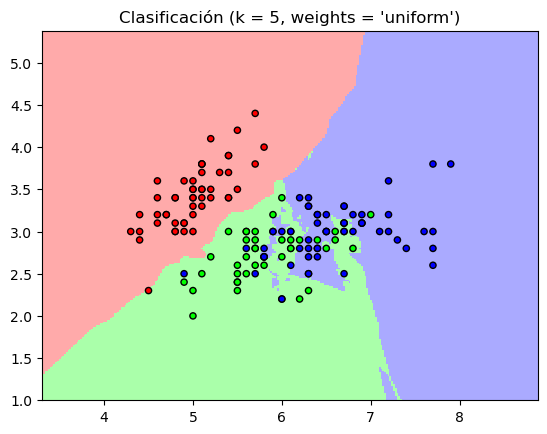

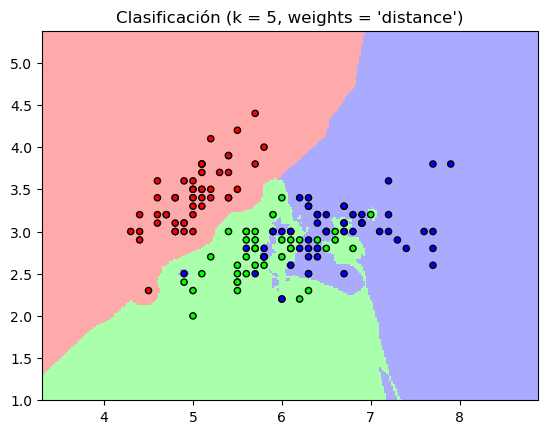

In [5]:
n_neighbors = 5

for weights in ['uniform', 'distance']:
    # Creamos una instancia del clasificador de vecinos más cercanos y le pasamos los datos mediante fit().
    # El primer parámetro de KNeighborsClassifier es con cuantos vecinos quiero clasificar y el
    # segundo el tipo de peso a utilizar.
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X, y)

    # Establecemos los límites del gráfico y asignamos un color a cada punto de malla.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Agregamos el resultado al gráfico
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, shading='auto', cmap=cmap_light)

    # Ploteo los datos de entrenamiento
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Clasificación (k = %i, weights = '%s')" % (n_neighbors, weights))
    plt.show()

In [6]:
#Ploteo un nuevo dato
Xn = np.array([[7.3,3], [5.1,2.9], [6.4,3.2]])
Yn = clf.predict(Xn)
print(Yn)

[2 0 1]


In [14]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [23]:
# Cargar dataset
iris = load_iris ()
X, Y = iris.data , iris.target
# Dividir en entrenamiento y test
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X, Y)
# Crear el árbol de decisión con profundidad máxima 3
arbol = DecisionTreeClassifier(max_depth=3)
# Entrenar el modelo
arbol.fit(X_entrenamiento, y_entrenamiento)
    


DecisionTreeClassifier(max_depth=3)

In [24]:
# Evaluar el modelo
print("Score test:", arbol.score(X_test, y_test))
print("Score entrenamiento:", arbol.score(X_entrenamiento, y_entrenamiento))

Score test: 0.9736842105263158
Score entrenamiento: 0.9732142857142857


In [27]:
# (Solo Windows) Agregar Graphviz al PATH
# os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'

# Exportar el árbol a archivo .dot
#export_graphviz(arbol,
#                out_file='arbol1.dot',
#                class_names=iris.target_names,
#                feature_names=iris.feature_names[:2],
#                impurity=False,
#                filled=True)
# Leer y visualizar el árbol
#with open('arbol1.dot') as f:
#    dot_graph = f.read()

#graphviz.Source(dot_graph)

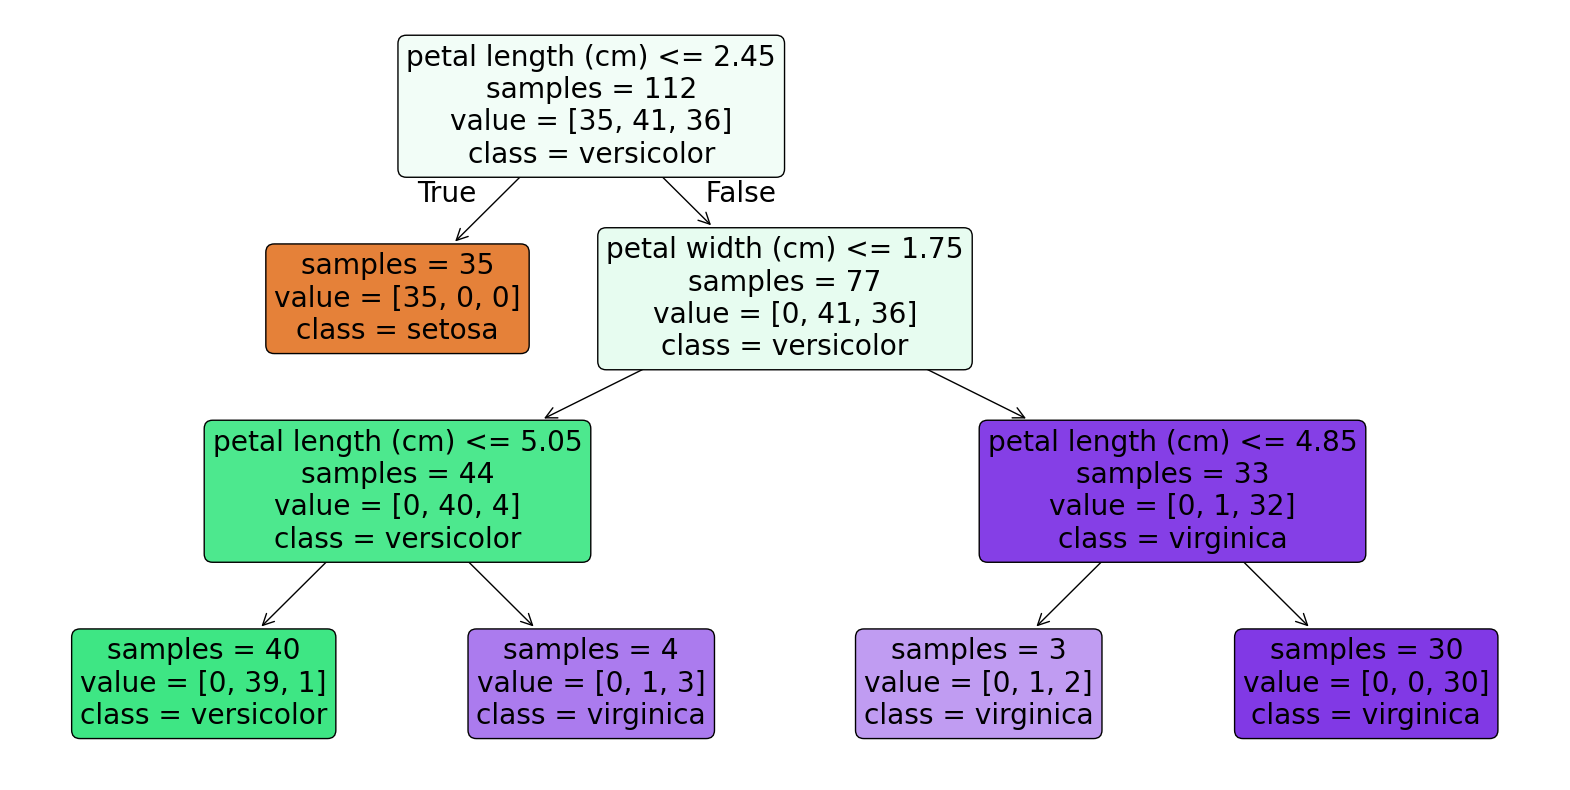

In [29]:
# Exportar directamente como string, sin archivo
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(arbol,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          impurity=False,
          rounded=True)
plt.show()

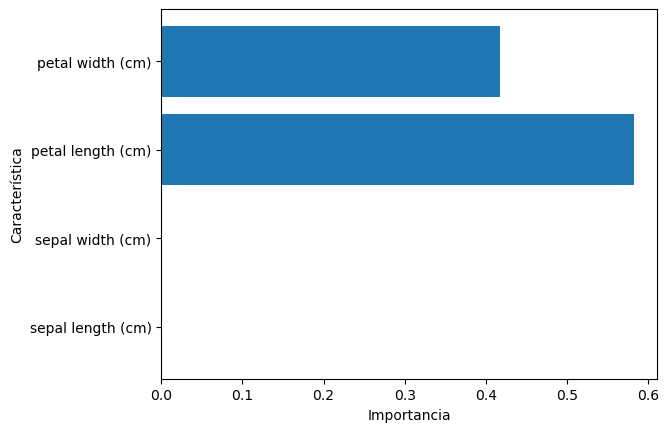

In [37]:
caracteristica = 4

plt.barh(range(caracteristica), arbol.feature_importances_)
plt.yticks(np.arange(caracteristica), iris.feature_names)
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()